<a href="https://colab.research.google.com/github/weagan/Multi-Token-Prediction-MTP-/blob/main/Meta_MTP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meta Multi-Token Prediction (MTP) Architecture Demo

This notebook implements a simple MTP-style architecture in PyTorch:

- A shared **trunk** (Transformer encoder used in causal mode)
- **K** parallel output heads predicting multiple future tokens per position
- A tensor formulation:

$$
Z_{b t k v} = H_{b t d} W_{k d v}, \quad
p_{b t k v} = \mathrm{softmax}_v(Z_{b t k v}), \quad
\mathcal{L} = -\frac{1}{\sum_{b,t,k} m_{b t k}} \sum_{b,t,k} m_{b t k} \log p_{b t k, x_{b, t+k}}
$$

where $m_{b t k}$ masks out positions where $t + k$ exceeds the sequence length.

We train on a synthetic token dataset, show training/validation losses, and run a small test inspection.

In [ ]:
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, *args, **kwargs: x

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU count:', torch.cuda.device_count())

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 1


In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

device

device(type='cuda')

## Hyperparameters and synthetic dataset

We use a small synthetic dataset of random token sequences just to exercise the architecture and loss.

In [ ]:
VOCAB_SIZE = 128
SEQ_LEN = 32
TRAIN_SAMPLES = 4000
VAL_SAMPLES = 1000
BATCH_SIZE = 64
D_MODEL = 512 # Increased from 256 to 512
N_LAYERS = 8  # Increased from 4 to 8
N_HEADS = 16 # Increased from 8 to 16
K_FUTURE = 15
MAX_EPOCHS = 50 # Increased from 30 to 50
LR = 3e-4
WARMUP_STEPS = 100

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Config set.')

Config set.


In [ ]:
class MeaningfulSequenceDataset(Dataset):
    def __init__(self, num_samples, seq_len, vocab_size):
        self.data = torch.empty((num_samples, seq_len), dtype=torch.long)
        self.denominators = [] # Store denominators for inspection

        # Helper to get digits for 1/n up to a certain length
        def get_fraction_digits(n, max_len):
            digits = []
            numerator = 1
            # Generate enough digits to cover the sequence length, plus some extra for cycles
            # The maximum cycle length for 1/n up to n=19 is 18 digits (for 1/19)
            # So, generating max_len * 2 digits ensures we capture repeating cycles.
            for _ in range(max_len * 2):
                numerator *= 10
                digit = numerator // n
                digits.append(digit)
                numerator %= n
                if numerator == 0 and len(digits) >= max_len: # Stop if terminating and we have enough digits
                    break
                if numerator == 0: # Terminating decimal, pad with 0s if not enough digits yet
                    while len(digits) < max_len * 2:
                        digits.append(0)
                    break
            return digits

        for i in range(num_samples):
            # Start with a random token for the first element
            self.data[i, 0] = random.randint(0, vocab_size - 1)

            # Choose a denominator for this sequence (from 2 to 19)
            denominator = random.randint(2, 19)
            self.denominators.append(denominator) # Store for potential debugging/inspection

            # Get the step pattern (digits) for this denominator
            step_pattern = get_fraction_digits(denominator, seq_len)

            # Generate subsequent tokens by cycling through the step_pattern
            for j in range(1, seq_len):
                # Use modulo to cycle through the step_pattern if it's shorter than seq_len
                step_size = step_pattern[(j - 1) % len(step_pattern)]

                self.data[i, j] = (self.data[i, j-1] + step_size) % vocab_size

    def __len__(self):
        return self.data.size(0)

    def __getitem__(self, idx):
        return self.data[idx]

train_ds = MeaningfulSequenceDataset(TRAIN_SAMPLES, SEQ_LEN, VOCAB_SIZE)
val_ds = MeaningfulSequenceDataset(VAL_SAMPLES, SEQ_LEN, VOCAB_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_ds), len(val_ds)

(4000, 1000)

## MTP model definition

We implement:

- Token + positional embeddings
- Transformer encoder used in causal mode (via an upper-triangular mask)
- A bank of **K** output heads with weights $W \in \mathbb{R}^{K \times d \times |V|}$
- A loss that predicts $x_{t+k}$ from $h_t$ for each head $k$

In [ ]:
class MTPModel(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, k_future, max_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.k_future = k_future
        self.max_len = max_len

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            batch_first=True,
            activation='gelu',
            dropout=0.3 # Increased dropout to 0.3
        )
        self.trunk = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # MTP heads: W in R^{K x d x V}
        self.W = nn.Parameter(torch.randn(k_future, d_model, vocab_size) / math.sqrt(d_model))

    def _causal_mask(self, T, device):
        # (T, T) mask with True where positions are masked
        mask = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)
        return mask

    def forward(self, x):
        """Forward pass returning logits of shape (B, T, K, V)."""
        B, T = x.shape
        assert T <= self.max_len, "Sequence length exceeds max_len"

        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        h = self.tok_emb(x) + self.pos_emb(pos)

        src_mask = self._causal_mask(T, x.device)
        h = self.trunk(h, mask=src_mask)

        # h: (B, T, d), W: (K, d, V) -> logits: (B, T, K, V)
        logits = torch.einsum('btd,kdv->btkv', h, self.W) #generate future tokens in parallel
        return logits

    def mtp_loss(self, x):
        """Compute MTP loss for input x (B, T)."""
        logits = self(x)  # (B, T, K, V)
        B, T, K, V = logits.shape
        device = x.device

        # time indices and future offsets
        t_idx = torch.arange(T, device=device).view(1, T, 1)          # (1, T, 1)
        k_idx = torch.arange(1, K + 1, device=device).view(1, 1, K)   # (1, 1, K)
        t_future = t_idx + k_idx                                      # (1, T, K)

        valid_mask = (t_future < T)                                   # (1, T, K)
        t_future_clamped = t_future.clamp(max=T - 1)                  # (1, T, K)

        x_expanded = x.unsqueeze(-1).expand(B, T, K)                  # (B, T, K)
        targets = torch.gather(
            x_expanded,
            1,
            t_future_clamped.expand(B, T, K)
        )                                                              # (B, T, K)

        log_probs = logits.log_softmax(dim=-1)                         # (B, T, K, V)
        log_probs_flat = log_probs.view(B * T * K, V)
        targets_flat = targets.view(B * T * K)

        loss_all = F.nll_loss(
            log_probs_flat,
            targets_flat,
            reduction='none'
        ).view(B, T, K)

        valid_mask_full = valid_mask.expand(B, T, K).float()
        loss = (loss_all * valid_mask_full).sum() / valid_mask_full.sum()
        return loss

model = MTPModel(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    k_future=K_FUTURE,
    max_len=SEQ_LEN
)

# Multi-GPU if available
if torch.cuda.device_count() > 1:
    print(f"Using DataParallel on {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)
sum(p.numel() for p in model.parameters())

26284032

The model generates the next `K_FUTURE` tokens in parallel for each position `t` using the `torch.einsum` operation within the `forward` method of the `MTPModel` class. Specifically, the line:

```python
logits = torch.einsum('btd,kdv->btkv', h, self.W)
```

performs a batched matrix multiplication. It takes the hidden states `h` of shape `(B, T, d)` (Batch, Time, Dimension) and multiplies it by the weight matrix `self.W` of shape `(K, d, V)` (K_Future, Dimension, Vocab_size). This results in `logits` of shape `(B, T, K, V)`, where `K` explicitly represents the `K_FUTURE` parallel predictions for `x_{t+1}, x_{t+2}, ..., x_{t+K_FUTURE}` for each position `t`.

## Optimizer and learning rate schedule

We use AdamW with a simple linear warmup + cosine decay schedule.

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = MAX_EPOCHS * math.ceil(len(train_loader))
print('Total training steps (approx):', total_steps)

def lr_schedule(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_schedule)

Total training steps (approx): 3150


## Training loop

We train for a few epochs and track training and validation losses.

In [ ]:
train_losses = []
val_losses = []

global_step = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]")
    for batch in pbar:
        x = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = model.module.mtp_loss(x) if isinstance(model, nn.DataParallel) else model.mtp_loss(x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * x.size(0)
        global_step += 1
        pbar.set_postfix({"loss": loss.item(), "lr": scheduler.get_last_lr()[0]})

    epoch_train_loss = running_loss / len(train_ds)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            loss = model.module.mtp_loss(x) if isinstance(model, nn.DataParallel) else model.mtp_loss(x)
            val_running += loss.item() * x.size(0)
    epoch_val_loss = val_running / len(val_ds)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch}: train_loss={epoch_train_loss:.4f}, val_loss={epoch_val_loss:.4f}")

train_losses, val_losses

Epoch 1 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1: train_loss=4.9654, val_loss=4.3415


Epoch 2 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2: train_loss=3.6590, val_loss=2.7202


Epoch 3 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 49 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49: train_loss=0.3657, val_loss=0.4335


Epoch 50 [train]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 50: train_loss=0.3657, val_loss=0.4335


([4.965442241668701,
  3.659041040420532,
  2.520770250320435,
  2.0205916843414307,
  1.6936529970169067,
  1.4676510314941407,
  1.2895337972640992,
  1.161294759273529,
  1.060139045238495,
  0.9819504957199097,
  0.9142386946678162,
  0.8538324480056763,
  0.805034430027008,
  0.7610655059814453,
  0.7241095623970032,
  0.688362370967865,
  0.656770712852478,
  0.628837477684021,
  0.6049961926937103,
  0.5813530988693237,
  0.5594377238750458,
  0.5401427292823792,
  0.5247579803466796,
  0.5065161616802215,
  0.49221536350250245,
  0.478704478263855,
  0.4667462284564972,
  0.45597499442100525,
  0.44540903425216677,
  0.43551115942001345,
  0.4276967461109161,
  0.41974426531791686,
  0.4126265728473663,
  0.4051934995651245,
  0.4007419033050537,
  0.39484284019470217,
  0.3908820939064026,
  0.38683156776428224,
  0.3824087476730347,
  0.37907821106910705,
  0.37694080400466917,
  0.37425795555114744,
  0.371511029958725,
  0.3695619468688965,
  0.36859884309768676,
  0.367470

## Loss curves

Quick visualization of training and validation losses.

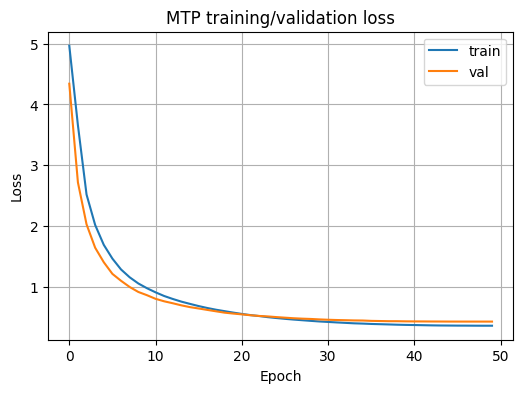

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MTP training/validation loss')
plt.legend()
plt.grid(True)
plt.show()

## Test run: inspect predictions

We take a batch from the validation set and inspect, for one sequence:

- The input tokens
- For a chosen position $t$ and head $k$, the model's top predictions vs. the true future token $x_{t+k}$.

In [ ]:
model.eval()
batch = next(iter(val_loader))
x = batch.to(device)

with torch.no_grad():
    logits = model(x)  # (B, T, K, V)

B, T, K, V = logits.shape
print('Batch shape:', x.shape)
print('Logits shape:', logits.shape, f" (K={K_FUTURE} predictions)")

b = 0 # Simply pick the first sequence from the batch

# Find a sequence with a non-zero denominator that is not 1 to show step pattern clearly
# We'll iterate through the batch to find one where the denominator is > 1 for better illustration
found_interesting_sequence = False
for batch_idx in range(B):
    if val_ds.denominators[batch_idx] > 1:
        b = batch_idx
        found_interesting_sequence = True
        break

if not found_interesting_sequence:
    print("Warning: Could not find a sequence with denominator > 1 in the current batch. Using batch index 0.")
    b = 0


t = min(5, T - 1) # Ensure t allows for K_FUTURE predictions without going out of bounds

x_cpu = x[b].cpu().tolist()
print(f'\nInput sequence (first 25 tokens) from batch index {b} (step pattern from 1/{val_ds.denominators[b]}):')
print(x_cpu[:25])

print(f"\nInspecting predictions from position t={t} for the next {K_FUTURE} tokens...")

correct_top1_predictions = 0

for k in range(1, K_FUTURE + 1):
    logits_btk = logits[b, t, k-1]  # (V,) (k-1 because K is 1-indexed in problem, 0-indexed in tensor)
    probs_btk = logits_btk.softmax(dim=-1)
    topk_display = 5
    top_probs, top_indices = torch.topk(probs_btk, topk_display)

    true_future_index = t + k
    if true_future_index < T:
        true_token = x_cpu[true_future_index]
    else:
        true_token = None # Target is out of sequence bounds

    print(f"\n--- Inspecting position t={t}, head k={k} (predicting token at t+k={true_future_index}) ---")
    print('True future token:', true_token)
    print('\nTop predictions (token, prob):')
    for i, (p, idx) in enumerate(zip(top_probs.cpu().tolist(), top_indices.cpu().tolist())):
        marker = ""
        if i == 0: # Only check the top prediction for the red X
            if idx == true_token:
                marker = " ✅"
                if true_token is not None:
                    correct_top1_predictions += 1
            else:
                marker = " ❌"
        # If the true token is not the top prediction but is in the top-k, still mark it with a check
        elif idx == true_token:
             marker = " ✅"
        print(f"  {idx:3d}  prob={p:.4f}{marker}")

print(f"\n\nSummary: {correct_top1_predictions} out of {K_FUTURE} top-1 predictions were correct for sequence {b} at position {t}.")


Batch shape: torch.Size([64, 32])
Logits shape: torch.Size([64, 32, 15, 128])  (K=15 predictions)

Input sequence (first 25 tokens) from batch index 0 (step pattern from 1/19):
[115, 115, 120, 122, 0, 3, 4, 9, 16, 24, 33, 37, 44, 47, 53, 61, 65, 67, 68, 68, 73, 75, 81, 84, 85]

Inspecting predictions from position t=5 for the next 15 tokens...

--- Inspecting position t=5, head k=1 (predicting token at t+k=6) ---
True future token: 4

Top predictions (token, prob):
    9  prob=0.2306 ❌
   11  prob=0.1370
    6  prob=0.1294
    4  prob=0.1111 ✅
   10  prob=0.0891

--- Inspecting position t=5, head k=2 (predicting token at t+k=7) ---
True future token: 9

Top predictions (token, prob):
    9  prob=0.3049 ✅
   65  prob=0.1109
   20  prob=0.0928
   24  prob=0.0825
   13  prob=0.0673

--- Inspecting position t=5, head k=3 (predicting token at t+k=8) ---
True future token: 16

Top predictions (token, prob):
   24  prob=0.4232 ❌
   16  prob=0.1818 ✅
   21  prob=0.1203
   20  prob=0.0385
   68